## Sample script for synchronizing images with Absorption data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#Specify csv file with absorption data and frame timing
data = pd.read_csv('Desktop/Ti2f_015_CW23_Spot on Bare Metal/Spot on Bare Metal_Calibrated Absorption Data_v2.csv', index_col=0, float_precision="high")

In [2]:
#Find index of frames

FrmNum = data.FrameNumber;
Frames = FrmNum.max();

n = 1;
frameIndex = [None]*Frames;               #list of indices at start of Frame
for p in FrmNum:
    if p == n:
        row = data.loc[data['FrameNumber'] == n]
        frameIndex[n-1] = row.index[0];
        n += 1;

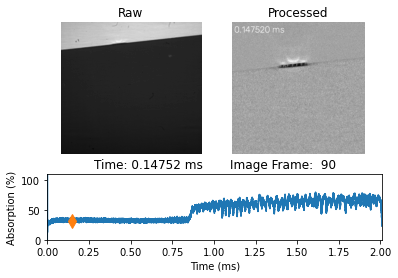

In [3]:
#Read in image that corresponds to Frame indices
import glob

#Input frame number that you would like to show.
Frame = 90; 

#Get the image matching frame number from the specified directory.
raw_imageFile = glob.glob('Desktop/Ti2f_015_CW23_Spot on Bare Metal/Spot on Bare Metal_Raw Xray Images/*' + str(Frame).zfill(3) + '.tif')
raw_img = plt.imread(raw_imageFile[0])
proc_imageFile = glob.glob('Desktop/Ti2f_015_CW23_Spot on Bare Metal/XrayImages_processed_captioned/*' + str(Frame).zfill(3) + '.tif')
proc_img = plt.imread(proc_imageFile[0])

#Show figure with raw and processed images with absorption data.
grid = plt.GridSpec(2, 2, wspace=0, hspace=0.2, width_ratios=[2, 2],height_ratios=[2, 1])

raw_plot = plt.subplot(grid[0, 0])
raw_plot.imshow(raw_img, cmap='gray');
raw_plot.title.set_text('Raw')
raw_plot.axis('off')
#raw_plot.figure(figsize=(3 ,3))

proc_plot = plt.subplot(grid[0, 1])
#plt.figure(figsize=(3 ,3))
proc_plot.imshow(proc_img, cmap='gray');
proc_plot.title.set_text('Processed')
proc_plot.axis('off')

abs_plot = plt.subplot(grid[1, 0:])
abs_plot.plot(data.Time*1000, data.RelativeAbsorption);
abs_plot.plot(data.Time[frameIndex[Frame-1]]*1000, data.RelativeAbsorption[frameIndex[Frame-1]], 'd', markersize=10);
abs_plot.set_ylim([0, 110]);
abs_plot.set_xlim([0, 2.01]);
abs_plot.set_ylabel("Absorption (%)");
abs_plot.set_xlabel("Time (ms)");
abs_plot.title.set_text('Time: {:.5f} ms       Image Frame: {:3d}'.format(data.Time[frameIndex[Frame-1]]*1000, Frame)) 

